<a href="https://colab.research.google.com/github/Dilshan-Pasindu/Machine-Learning--Lab/blob/main/IT24101554_Lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

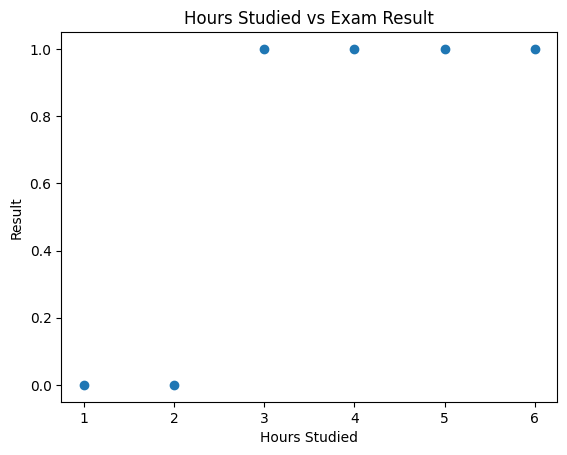

In [17]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5, 6])
Y = np.array([0, 0, 1, 1, 1, 1])

plt.scatter(X, Y)
plt.xlabel("Hours Studied")
plt.ylabel("Result")
plt.title("Hours Studied vs Exam Result")
plt.show()

In [18]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

theta0 = 0
theta1 = 0

z = theta0 + theta1 * X
probabilities = sigmoid(z)

print(probabilities)

[0.5 0.5 0.5 0.5 0.5 0.5]


In [19]:
def log_loss(y, h):
    epsilon = 1e-9
    h = np.clip(h, epsilon, 1 - epsilon)

    return -np.mean(
        y * np.log(h) +
        (1 - y) * np.log(1 - h)
    )

initial_loss = log_loss(Y, probabilities)

print("Initial Log-Loss:", initial_loss)


Initial Log-Loss: 0.6931471805599453


In [20]:
theta0 = 0
theta1 = 0

alpha = 0.1
iterations = 50

cost_history = []

for i in range(iterations):

    z = theta0 + theta1 * X
    h = sigmoid(z)

    # Calculate gradients
    gradient0 = np.mean(h - Y)
    gradient1 = np.mean((h - Y) * X)

    # Update parameters
    theta0 = theta0 - alpha * gradient0
    theta1 = theta1 - alpha * gradient1

    # Calculate cost
    cost = log_loss(Y, h)
    cost_history.append(cost)

print("Final theta0:", theta0)
print("Final theta1:", theta1)

Final theta0: -0.4968051521381864
Final theta1: 0.567975480116632


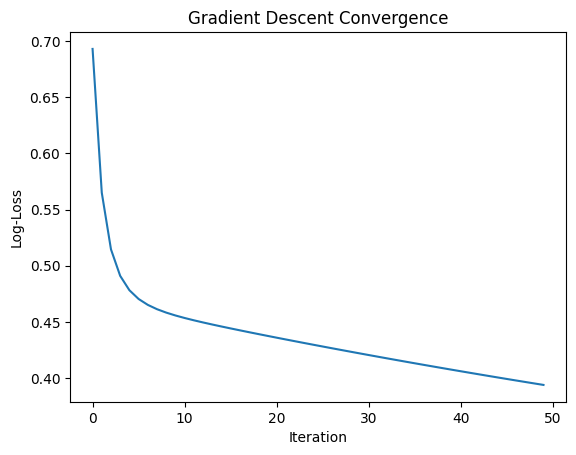

In [21]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Log-Loss")
plt.title("Gradient Descent Convergence")
plt.show()

In [22]:
def predict_probability(x):
    z = theta0 + theta1 * x
    return sigmoid(z)

def predict_class(x, threshold=0.5):
    probability = predict_probability(x)

    if probability >= threshold:
        return 1
    else:
        return 0

x_new = 2.5

probability = predict_probability(x_new)

print("Probability:", probability)
print("Class:", predict_class(x_new))

Probability: 0.715680157266271
Class: 1


In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X.reshape(-1, 1), Y)

probability = model.predict_proba([[2.5]])
prediction = model.predict([[2.5]])

print("Probability:", probability)
print("Prediction:", prediction)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Probability: [[0.47401274 0.52598726]]
Prediction: [1]
Intercept: [-2.59584271]
Coefficient: [[1.0799542]]


In [24]:
X_train = np.array([
    [1, 1],
    [2, 1.5],
    [2, 3],
    [4, 5],
    [5, 4.5],
    [5, 2.5]
])

y_train = np.array([0, 0, 0, 1, 1, 1])

Q = np.array([4, 2])

def euclidean_distance(p, q):
    return np.sqrt(np.sum((p - q) ** 2))

distances = []

for i in range(len(X_train)):
    d = euclidean_distance(X_train[i], Q)
    distances.append((i, d))

distances.sort(key=lambda x: x[1])

print(distances)

[(5, np.float64(1.118033988749895)), (1, np.float64(2.0615528128088303)), (2, np.float64(2.23606797749979)), (4, np.float64(2.692582403567252)), (3, np.float64(3.0)), (0, np.float64(3.1622776601683795))]


In [25]:
k = 3

# Sort distances by distance value

distances.sort(key=lambda x: x[1])

# Select 3 nearest neighbors

nearest = distances[:k]

print("3 Nearest Neighbors:")

for index, distance in nearest:

    print(

        "Student:", chr(65 + index),

        "Distance:", round(distance, 3),

        "Class:", y_train[index]

    )

# Majority voting

labels = [y_train[index] for index, distance in nearest]

prediction = max(set(labels), key=labels.count)

print("Predicted Class:", prediction)

3 Nearest Neighbors:
Student: F Distance: 1.118 Class: 1
Student: B Distance: 2.062 Class: 0
Student: C Distance: 2.236 Class: 0
Predicted Class: 0


In [27]:
from collections import Counter
import numpy as np

def knn_predict(X_train, y_train, query, k):

    distances = []

    # Calculate distances
    for i in range(len(X_train)):
        distance = np.sqrt(
            np.sum((X_train[i] - query) ** 2)
        )
        distances.append((distance, y_train[i]))

    # Sort by distance
    distances.sort(key=lambda x: x[0])

    # Select k nearest neighbors
    nearest = distances[:k]

    # Get their class labels
    labels = [label for distance, label in nearest]

    # Majority vote
    prediction = Counter(labels).most_common(1)[0][0]

    return prediction

In [28]:
Q = np.array([4, 2])

for k in [1, 3, 5]:
    prediction = knn_predict(X_train, y_train, Q, k)
    result = "Pass" if prediction == 1 else "Fail"

    print(f"k = {k}: {result} ({prediction})")

k = 1: Pass (1)
k = 3: Fail (0)
k = 5: Pass (1)


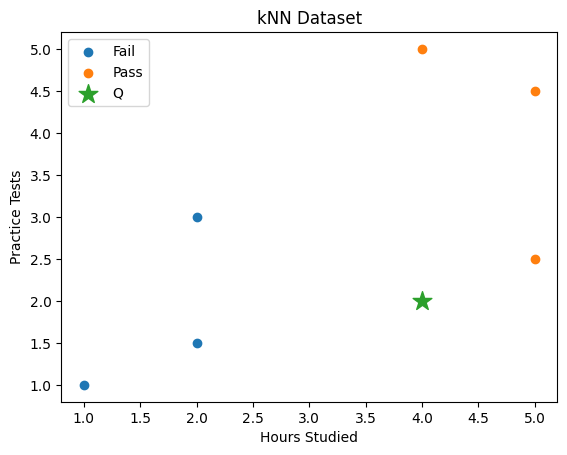

In [29]:
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Fail"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Pass"
)

plt.scatter(
    Q[0],
    Q[1],
    marker="*",
    s=200,
    label="Q"
)

plt.xlabel("Hours Studied")
plt.ylabel("Practice Tests")
plt.title("kNN Dataset")
plt.legend()
plt.show()

In [30]:
from collections import Counter

def knn_predict(X_train, y_train, query, k):

    distances = []

    # 1. Calculate distances
    for i in range(len(X_train)):
        distance = np.sqrt(
            np.sum((X_train[i] - query) ** 2)
        )

        distances.append((distance, y_train[i]))

    # 2. Sort distances
    distances.sort(key=lambda x: x[0])

    # 3. Select k nearest
    nearest = distances[:k]

    # 4. Obtain labels
    labels = [label for distance, label in nearest]

    # 5. Majority voting
    prediction = Counter(labels).most_common(1)[0][0]

    # 6. Return prediction
    return prediction

In [31]:
prediction = knn_predict(
    X_train,
    y_train,
    Q,
    3
)

print("Prediction:", prediction)

Prediction: 0


In [32]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# --------------------------------
# 1. Create the training dataset
# --------------------------------

X_train = np.array([
    [1, 1],
    [2, 1.5],
    [2, 3],
    [4, 5],
    [5, 4.5],
    [5, 2.5]
])

y_train = np.array([0, 0, 0, 1, 1, 1])

# 0 = Fail
# 1 = Pass


# --------------------------------
# 2. Create the query point
# --------------------------------

Q = np.array([4, 2])


# --------------------------------
# 3. Create kNN model
# --------------------------------

knn = KNeighborsClassifier(n_neighbors=3)


# --------------------------------
# 4. Train the model
# --------------------------------

knn.fit(X_train, y_train)


# --------------------------------
# 5. Predict the class
# --------------------------------

prediction = knn.predict([Q])

print("Prediction:", prediction)


# --------------------------------
# 6. Convert prediction to label
# --------------------------------

if prediction[0] == 1:
    print("Predicted Result: Pass")
else:
    print("Predicted Result: Fail")


# --------------------------------
# 7. Get class probabilities
# --------------------------------

probability = knn.predict_proba([Q])

print("Class Probabilities:", probability)

Prediction: [0]
Predicted Result: Fail
Class Probabilities: [[0.66666667 0.33333333]]


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

Q_scaled = scaler.transform([Q])

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_scaled, y_train)

prediction = knn.predict(Q_scaled)

print(prediction)

[0]
